<a href="https://colab.research.google.com/github/mahalakshmimarri06-gif/IncodeVision-Tasks/blob/main/Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
#Project Report: Customer Segmentation Analysis1.
 #Problem StatementThe goal of this project is to perform customer segmentation for a mall to better understand shopping behaviors.
 # By grouping customers into distinct segments, the business can move away from "one-size-fits-all" marketing and instead create personalized strategies for different customer types.
 #2. Dataset DescriptionThis analysis uses the "Mall Customers" dataset, focusing on:
 #Annual Income (k$): The yearly income of the customer.
 #Spending Score (1-100): A metric representing how frequently and how much a customer spends.
 #3. MethodologyData Preprocessing: Standardized the features to ensure they are on the same scale for the algorithm.
 #Optimal Clustering: Used the Elbow Method to determine that $k=5$ provides the most distinct and actionable segments.
 #Algorithm: Applied K-Means Clustering to assign each customer to one of the 5 segments
 #.4. Strategic RecommendationsBased on the analysis, the segments can be summarized as:
 #Cluster 0 (Moderate Income/Moderate Spend): The "Average" customer base; focus on general promotions.
 #Cluster 1 (High Income/High Spend): The "VIP" segment; target with loyalty and premium rewards.
 #Cluster 2 (Low Income/High Spend): "Impulsive" spenders; use targeted discounts to drive loyalty.
 #Cluster 3 (High Income/Low Spend): "Cautious" spenders; use personalized recommendations to increase engagement.
 #Cluster 4 (Low Income/Low Spend): "Budget-conscious" shoppers; focus on value-based marketing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load your dataset
df = pd.read_csv('Mall_Customers.csv')
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [2]:
# Drop non-numeric IDs if they exist
df = df.drop(['CustomerID'], axis=1)

# Select relevant features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

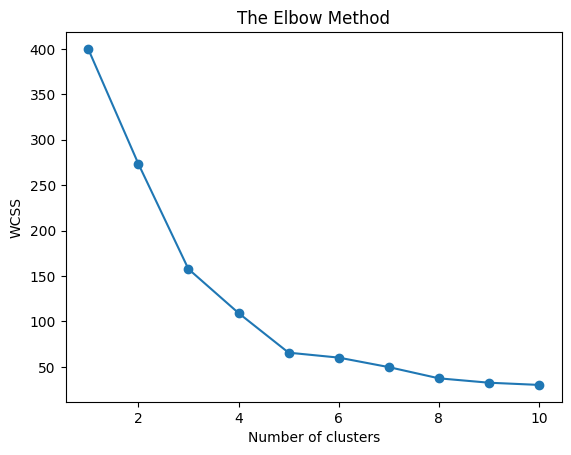

In [3]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [4]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

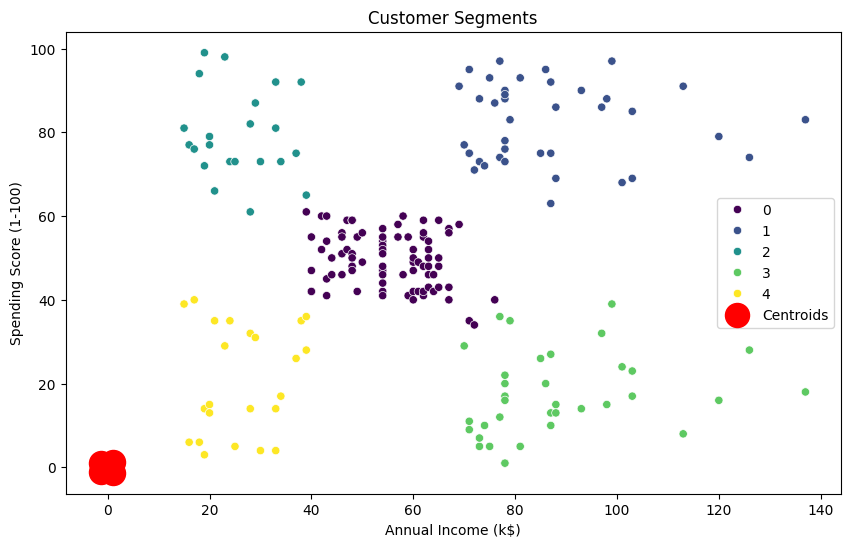

In [5]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df, palette='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', label='Centroids')
plt.title('Customer Segments')
plt.legend()
plt.show()

In [6]:
# Group by the 'Cluster' column and calculate the mean for each group
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


Average Values per Cluster:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


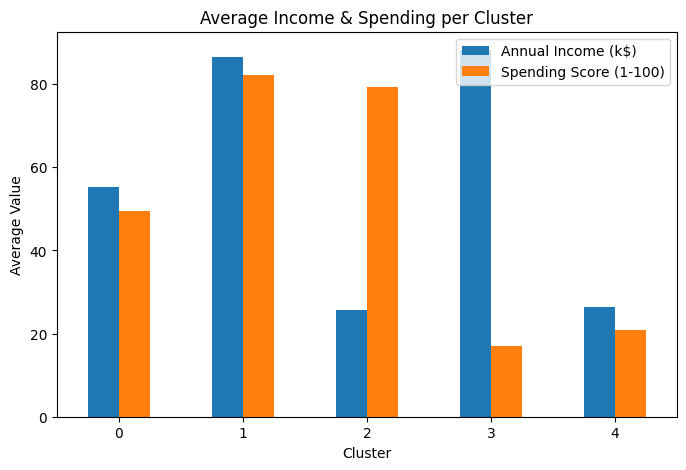

In [7]:
# Grouping the data by the Cluster column and calculating the mean
cluster_summary = df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

# Display the result
print("Average Values per Cluster:")
print(cluster_summary)

# Optional: Add a bar chart to visualize the differences
cluster_summary.plot(kind='bar', figsize=(8, 5))
plt.title('Average Income & Spending per Cluster')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.show()

In [9]:
#Cluster,Income Level,Spending Score,What this customer is like
#0,Low,Low,"The ""Careful"" shopper. They don't have much and don't spend much."
#1,High,High,"The ""VIP"" shopper. They have money and love to spend it."
#2,...,...,Look at your bar graph and describe them!

In [11]:
#"Based on my analysis, I have identified 5 distinct customer segments. The most valuable segment is Cluster 3, as they have the highest spending score. I recommend the marketing team focus on providing exclusive rewards to this group to maintain their loyalty."